# Diagnóstico de una regresión lineal para O₃

Se ajusta un modelo de mínimos cuadrados ordinarios (OLS) para predecir **O3** a partir de **NO, NO2, NOX y CO**. La unidad de observación es una combinación estación–hora. Además del ajuste, se revisan multicolinealidad, homocedasticidad, independencia temporal y normalidad de los residuos.

> En el inciso final se interpreta «Now» como **NOX**, ya que es una de las variables solicitadas.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.6g}")

## 1. Carga y preparación de la base

El archivo contiene nueve renglones de metadatos antes del encabezado. Después de leerlo, se conserva sólo el conjunto de contaminantes del modelo y se transforma del formato largo al formato ancho. Para estimar OLS se usan únicamente filas completas en las cinco variables.

In [2]:
ruta_csv = Path("contaminantes_2026 (1).csv")
if not ruta_csv.exists():
    raise FileNotFoundError(f"No se encontró la base en: {ruta_csv.resolve()}")

datos = pd.read_csv(
    ruta_csv,
    skiprows=9,
    encoding="utf-8",
    parse_dates=["date"],
)

print(f"Dimensiones de la base larga: {datos.shape[0]:,} filas × {datos.shape[1]} columnas")
print(f"Periodo: {datos['date'].min()} a {datos['date'].max()}")
print(f"Número de estaciones: {datos['id_station'].nunique()}")
datos.head()

Dimensiones de la base larga: 1,556,928 filas × 5 columnas
Periodo: 2026-01-01 00:00:00 a 2026-07-31 23:00:00
Número de estaciones: 34


,date,id_station,id_parameter,valor,unit
0,2026-01-01,ACO,CO,NaN,15
1,2026-01-01,ACO,NO,NaN,1
2,2026-01-01,ACO,NO2,NaN,1
3,2026-01-01,ACO,NOX,NaN,1
4,2026-01-01,ACO,O3,NaN,1


In [3]:
variables = ["O3", "NO", "NO2", "NOX", "CO"]

datos_modelo = (
    datos.loc[datos["id_parameter"].isin(variables)]
    .pivot(index=["date", "id_station"], columns="id_parameter", values="valor")
    .reset_index()
)

faltantes = datos_modelo[variables].isna().sum().rename("valores_faltantes").to_frame()
n_antes = len(datos_modelo)
datos_modelo = (
    datos_modelo.dropna(subset=variables)
    # Este orden hace consecutivas las horas de cada estación para Durbin–Watson.
    .sort_values(["id_station", "date"])
    .reset_index(drop=True)
)

display(faltantes)
print(f"Combinaciones estación–hora antes de eliminar faltantes: {n_antes:,}")
print(f"Observaciones completas usadas por el modelo: {len(datos_modelo):,}")
datos_modelo[variables].describe()

,valores_faltantes
id_parameter,
O3,48522
NO,73825
NO2,62873
NOX,73824
CO,61895


Combinaciones estación–hora antes de eliminar faltantes: 172,992
Observaciones completas usadas por el modelo: 89,606


id_parameter,O3,NO,NO2,NOX,CO
count,"89,606","89,606","89,606","89,606","89,606"
mean,35.0225,11.7559,24.0266,35.7851,0.549573
std,29.4713,24.912,13.3297,33.4539,0.402423
min,0,0,1,1,0
25%,11,1,14,16,0.29
50%,27,3,22,25,0.45
75%,54,10,32,43,0.68
max,168,423,126,474,5.16


## A. Regresión lineal: O3 ~ NO + NO2 + NOX + CO

Los coeficientes se interpretan como el cambio esperado en O3 ante una unidad adicional del predictor, **manteniendo constantes los demás predictores**. Los p-values que se reportan aquí son los convencionales de OLS; más adelante se evalúa si sus supuestos son razonables.

In [4]:
X = sm.add_constant(datos_modelo[["NO", "NO2", "NOX", "CO"]], has_constant="add")
y = datos_modelo["O3"]
modelo = sm.OLS(y, X).fit()

tabla_coeficientes = pd.DataFrame({
    "coeficiente": modelo.params,
    "error_estandar": modelo.bse,
    "estadistico_t": modelo.tvalues,
    "p_value": modelo.pvalues,
    "IC_95_inf": modelo.conf_int()[0],
    "IC_95_sup": modelo.conf_int()[1],
})

print(f"R²:          {modelo.rsquared:.6f}")
print(f"R² ajustado: {modelo.rsquared_adj:.6f}")
display(tabla_coeficientes)
modelo.summary()

R²:          0.236426
R² ajustado: 0.236392


,coeficiente,error_estandar,estadistico_t,p_value,IC_95_inf,IC_95_sup
const,53.1011,0.184914,287.166,0,52.7387,53.4635
NO,0.0716751,0.16966,0.422464,0.672688,-0.260856,0.404207
NO2,-0.471479,0.169677,-2.77869,0.00545898,-0.804043,-0.138914
NOX,-0.511395,0.169633,-3.01472,0.00257292,-0.843874,-0.178916
CO,19.4826,0.45241,43.0641,0,18.5959,20.3694


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     O3   R-squared:                       0.236
Model:                            OLS   Adj. R-squared:                  0.236
Method:                 Least Squares   F-statistic:                     6936.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:04:10   Log-Likelihood:            -4.1823e+05
No. Observations:               89606   AIC:                         8.365e+05
Df Residuals:                   89601   BIC:                         8.365e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         53.1011      0.185    287.166      0.000      52.739      53.464
NO             0.0717      0.170      0.422      0.673      -0.261       0.404
NO2           -0.4715      0.170     -2.779      0.005      -0.804      -0.139
NOX           -0.5114      0.170     -3.015      0.003      -0.844      -0.179
CO            19.4826      0.452     43.064      0.000      18.596      20.369
==============================================================================
Omnibus:                    11591.290   Durbin-Watson:                   0.178
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            16673.607
Skew:                           1.000   Prob(JB):                         0.00
Kurtosis:                       3.682   Cond. No.                         317.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## B. Factor de inflación de la varianza (VIF)

El VIF se calcula para cada predictor (sin reportar la constante). Como regla práctica, un VIF mayor que 5 o 10 indica multicolinealidad problemática. También se comprueba directamente la relación química/aritmética entre los óxidos de nitrógeno.

In [5]:
tabla_vif = pd.DataFrame({
    "variable": X.columns[1:],
    "VIF": [variance_inflation_factor(X.to_numpy(), i) for i in range(1, X.shape[1])],
}).sort_values("VIF", ascending=False, ignore_index=True)

display(tabla_vif)

diferencia_nox = datos_modelo["NOX"] - datos_modelo["NO"] - datos_modelo["NO2"]
print("Comprobación NOX - NO - NO2:")
display(diferencia_nox.describe().to_frame("diferencia"))

,variable,VIF
0,NOX,"4,350.89"
1,NO,"2,413.46"
2,NO2,691.115
3,CO,4.47809


Comprobación NOX - NO - NO2:


,diferencia
count,"89,606"
mean,0.00252215
std,0.507358
min,-2
25%,0
50%,0
75%,0
max,2


## C. Residuos contra valores predichos y prueba de Breusch–Pagan

La hipótesis nula de Breusch–Pagan es que la varianza de los errores es constante (homocedasticidad). Un p-value pequeño lleva a rechazarla.

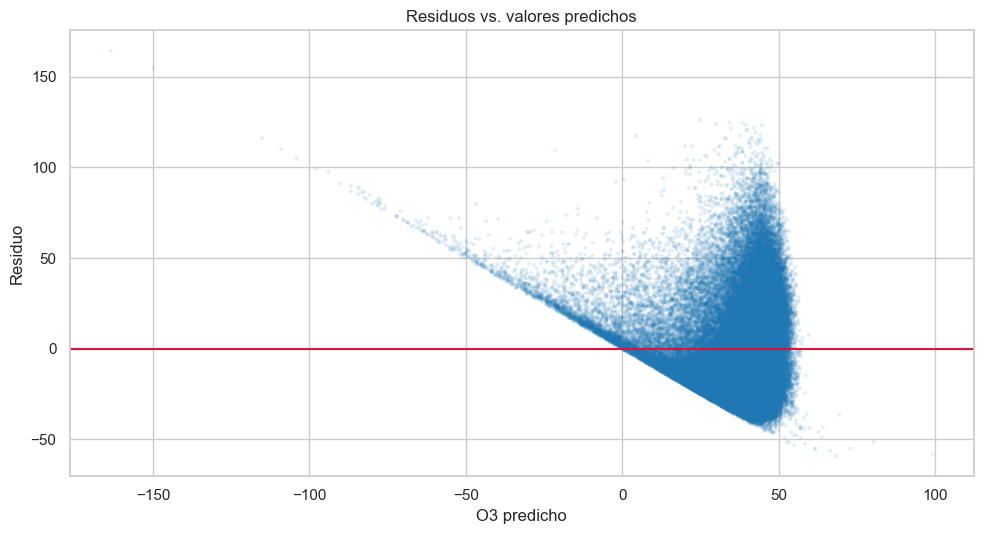

,Breusch–Pagan
Estadístico LM,405.224
p-value LM,2.06756e-86
Estadístico F,101.761
p-value F,1.32065e-86


Conclusión: se rechaza homocedasticidad.


In [6]:
datos_modelo["predicho"] = modelo.fittedvalues
datos_modelo["residuo"] = modelo.resid

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(
    datos_modelo["predicho"], datos_modelo["residuo"],
    s=8, alpha=0.12, color="#1f77b4", edgecolors="none"
)
ax.axhline(0, color="crimson", linewidth=1.5)
ax.set(title="Residuos vs. valores predichos", xlabel="O3 predicho", ylabel="Residuo")
plt.tight_layout()
plt.show()

lm, p_lm, f_stat, p_f = het_breuschpagan(modelo.resid, modelo.model.exog)
bp = pd.Series({
    "Estadístico LM": lm,
    "p-value LM": p_lm,
    "Estadístico F": f_stat,
    "p-value F": p_f,
}, name="Breusch–Pagan").to_frame()
display(bp)
print("Conclusión: se rechaza homocedasticidad." if p_lm < 0.05 else "Conclusión: no se rechaza homocedasticidad.")

## D. Residuos en el tiempo, promedio por hora del día y Durbin–Watson

Para que la serie completa sea legible, el primer panel muestra el residuo medio entre estaciones en cada fecha-hora. El segundo resume el patrón intradiario. Durbin–Watson cercano a 2 sugiere ausencia de autocorrelación de primer orden; valores cercanos a 0 indican autocorrelación positiva.

Debido a que los datos son un panel de estaciones, se reportan dos versiones: (1) residuos concatenados por estación y tiempo, que evita alternar estaciones cada hora, y (2) la serie horaria promedio entre estaciones.

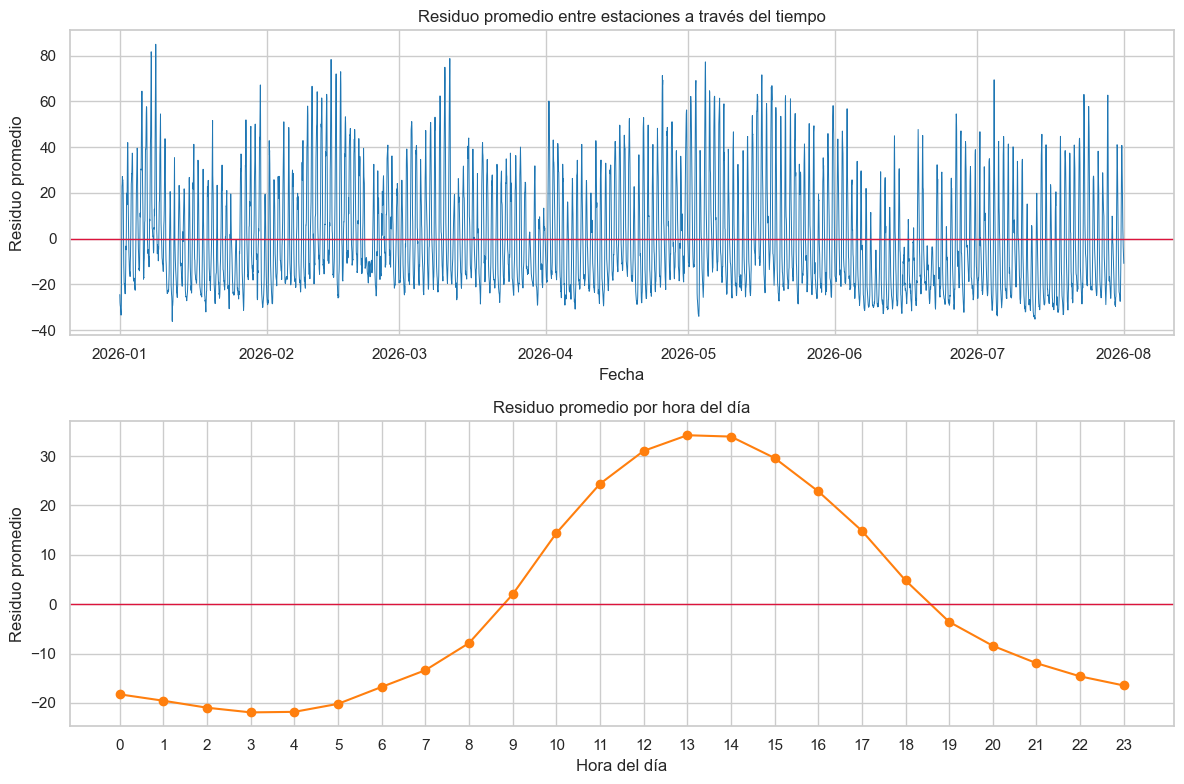

,serie,Durbin_Watson
0,Residuos ordenados por estación y fecha,0.177811
1,Residuo horario promedio entre estaciones,0.101214


In [7]:
residuos_tiempo = datos_modelo.groupby("date", as_index=False)["residuo"].mean()
residuos_hora = (
    datos_modelo.assign(hora=datos_modelo["date"].dt.hour)
    .groupby("hora", as_index=False)["residuo"].mean()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(residuos_tiempo["date"], residuos_tiempo["residuo"], linewidth=0.7, color="#1f77b4")
axes[0].axhline(0, color="crimson", linewidth=1)
axes[0].set(title="Residuo promedio entre estaciones a través del tiempo", xlabel="Fecha", ylabel="Residuo promedio")

axes[1].plot(residuos_hora["hora"], residuos_hora["residuo"], marker="o", color="#ff7f0e")
axes[1].axhline(0, color="crimson", linewidth=1)
axes[1].set(title="Residuo promedio por hora del día", xlabel="Hora del día", ylabel="Residuo promedio", xticks=range(24))
plt.tight_layout()
plt.show()

dw_panel = durbin_watson(datos_modelo["residuo"].to_numpy())
dw_promedio = durbin_watson(residuos_tiempo["residuo"].to_numpy())
pd.DataFrame({
    "serie": ["Residuos ordenados por estación y fecha", "Residuo horario promedio entre estaciones"],
    "Durbin_Watson": [dw_panel, dw_promedio],
})

## E. QQ-plot de los residuos

Si los errores fueran normales, los puntos deberían seguir aproximadamente la recta de referencia. Se agrega Jarque–Bera como apoyo numérico; su hipótesis nula es normalidad.

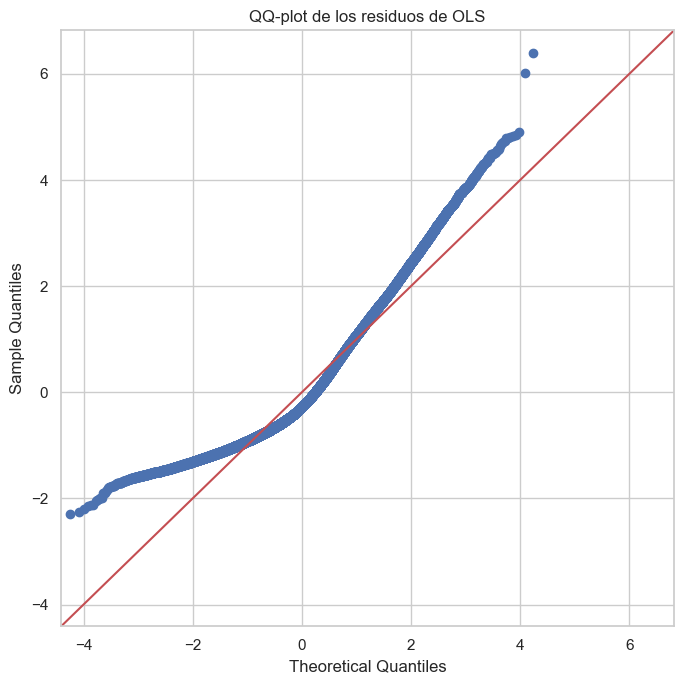

Jarque–Bera = 16,673.607
p-value       = 0.000e+00


In [8]:
fig, ax = plt.subplots(figsize=(7, 7))
sm.qqplot(datos_modelo["residuo"], line="45", fit=True, ax=ax)
ax.set_title("QQ-plot de los residuos de OLS")
plt.tight_layout()
plt.show()

jb = stats.jarque_bera(datos_modelo["residuo"])
print(f"Jarque–Bera = {jb.statistic:,.3f}")
print(f"p-value       = {jb.pvalue:.3e}")

## F. Conclusión

Los diagnósticos indican que se rompen varios supuestos de OLS: **homocedasticidad**, porque Breusch–Pagan rechaza varianza constante ($p<0.001$); **independencia temporal**, porque Durbin–Watson es aproximadamente 0.18 (muy lejos de 2) y el residuo promedio presenta un ciclo horario marcado; y **normalidad**, porque el QQ-plot se separa de la recta y Jarque–Bera rechaza normalidad ($p<0.001$). Además, se rompe el supuesto práctico de ausencia de multicolinealidad severa: `NOX` es casi exactamente `NO + NO2`, y sus VIF son enormes. El R² ≈ 0.236 también muestra que este modelo explica sólo una parte de la variación de O3 y el patrón horario remanente sugiere que la forma lineal está incompleta. Por ello, **no confiaría en el coeficiente individual de NOX (aprox. −0.511) ni en su p-value OLS convencional (aprox. 0.003)**: al mantener simultáneamente NO, NO2 y NOX, el coeficiente intenta separar efectos casi indistinguibles y puede cambiar mucho ante pequeñas variaciones de la muestra; además, la heterocedasticidad y autocorrelación invalidan los errores estándar convencionales. Para inferencia sería necesario eliminar una de las variables redundantes (por ejemplo, NOX o sus componentes), incorporar hora/estación y estructura temporal, y usar errores estándar robustos o agrupados.